In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Data directory
DATA_DIR_HDC = Path('../data/')

print('Libraries loaded successfully')
print(f'HDC data directory: {DATA_DIR_HDC}')

# Load column mapping config
import json

Libraries loaded successfully
HDC data directory: ../data


In [2]:
# Read in 1 dataset to get sense of structure
VAR_PREFIX = 'hh_et0'
data_dir = Path(f"{DATA_DIR_HDC}/{VAR_PREFIX}")
csv_files = sorted(data_dir.glob("*.csv"))

df = pd.read_csv(csv_files[0])
df['time'] = pd.to_datetime(df['time'])

In [3]:
print(df.head(5))
print()
print(f"Time range: {df.time.min()} - {df.time.max()}")

# time diff
df = df.sort_values('time')
df['time_diff'] = df['time'].diff()
df['time_diff'].value_counts()

# data is generally dekadal

    zone       time      mean           sum
0  10001 2008-01-01  8.130321  10276.724609
1  10001 2008-01-11  6.733525   8511.175781
2  10001 2008-01-21  7.687081   9716.470703
3  10001 2008-02-01  8.619191  10894.658203
4  10001 2008-02-11  8.841833  11176.077148

Time range: 2008-01-01 00:00:00 - 2022-12-21 00:00:00


time_diff
10 days    420
11 days    104
8 days      11
9 days       4
Name: count, dtype: int64

### Data ingestion

In [4]:
# do this with all csvs
VAR_PREFIX = 'hh_et0'
data_dir = Path(f"{DATA_DIR_HDC}/{VAR_PREFIX}")
csv_files = sorted(data_dir.glob("*.csv"))

df_all_et0 = pd.concat(
    (pd.read_csv(f) for f in csv_files),
    ignore_index=True
)

df_all_et0['time'] = pd.to_datetime(df_all_et0['time'])

print(f"{df_all_et0.shape=}")
print(f"Num unique HHs: {df_all_et0.zone.nunique()}")
print(f"Time range: {df_all_et0.time.min()} - {df_all_et0.time.max()}")

# time diff
df_all_et0 = df_all_et0.sort_values(['zone', 'time'])
df_all_et0['time_diff'] = df_all_et0.groupby('zone')['time'].diff()
print('\n', df_all_et0['time_diff'].value_counts())

# years
df_all_et0['year'] = df_all_et0['time'].dt.year
print('\n', df_all_et0['year'].value_counts())

df_all_et0.shape=(1140480, 6)
Num unique HHs: 1056
Time range: 2008-01-01 00:00:00 - 2022-12-21 00:00:00

 time_diff
0 days     570240
10 days    443520
11 days    109824
8 days      11616
9 days       4224
Name: count, dtype: int64

 year
2008    76032
2009    76032
2010    76032
2011    76032
2012    76032
2013    76032
2014    76032
2015    76032
2016    76032
2017    76032
2018    76032
2019    76032
2020    76032
2021    76032
2022    76032
Name: count, dtype: int64


In [5]:
failed_read_ls = [] # list of files that could not be read in

for var in ['hh_et0', 'hh_lai', 'hh_lst', 'hh_ndvi', 'hh_precip']: 
    data_dir = Path(f"{DATA_DIR_HDC}/{var}")
    csv_files = sorted([f for f in data_dir.glob("*.csv") if f.name != "appended_df.csv"])

    df_all_var = pd.DataFrame()

    for f in csv_files:
        try:
            temp = pd.read_csv(f)
            df_all_var = pd.concat([df_all_var, temp], ignore_index=True)
        except:
            failed_read_ls.append(f)

    df_all_var['time'] = pd.to_datetime(df_all_var['time'])

    df_all_var.columns = [f"{c}_{var}" if c not in ['zone', 'time'] else c for c in df_all_var.columns]
    df_all_var.to_csv(f"{DATA_DIR_HDC}/{var}/appended_df.csv", index=False)
    print(f"+++ {var} +++\ncols: {df_all_var.columns}\nshape:{df_all_var.shape}\n")

    print(f"Num unique HHs: {df_all_var.zone.nunique()}")
    print(f"Time range: {df_all_var.time.min()} - {df_all_var.time.max()}")

    # time diff
    df_all_var = df_all_var.sort_values(['zone', 'time'])
    df_all_var['time_diff'] = df_all_var.groupby('zone')['time'].diff()
    print('\n', df_all_var['time_diff'].value_counts())

    # years
    df_all_var['year'] = df_all_var['time'].dt.year
    print('\n', df_all_var['year'].value_counts())

print(f"Failed files: {failed_read_ls}")

+++ hh_et0 +++
cols: Index(['zone', 'time', 'mean_hh_et0', 'sum_hh_et0'], dtype='object')
shape:(570240, 4)

Num unique HHs: 1056
Time range: 2008-01-01 00:00:00 - 2022-12-21 00:00:00

 time_diff
10 days    443520
11 days    109824
8 days      11616
9 days       4224
Name: count, dtype: int64

 year
2008    38016
2009    38016
2010    38016
2011    38016
2012    38016
2013    38016
2014    38016
2015    38016
2016    38016
2017    38016
2018    38016
2019    38016
2020    38016
2021    38016
2022    38016
Name: count, dtype: int64
+++ hh_lai +++
cols: Index(['zone', 'time', 'mean_hh_lai', 'sum_hh_lai'], dtype='object')
shape:(1455552, 4)

Num unique HHs: 1064
Time range: 2008-01-01 00:00:00 - 2022-12-27 00:00:00

 time_diff
4 days     1435336
1 days       10640
2 days        4256
16 days       2128
8 days        1064
20 days       1064
Name: count, dtype: int64

 year
2008    97888
2009    97888
2010    97888
2011    97888
2012    97888
2013    97888
2014    97888
2015    97888
2017   

In [6]:
data_dir = Path(DATA_DIR_HDC) # Use your existing path variable
variables = ['hh_et0', 'hh_lai', 'hh_lst', 'hh_ndvi', 'hh_precip']

master_df = pd.read_csv(data_dir / variables[0] / "appended_df.csv")
master_df['time'] = pd.to_datetime(master_df['time'])

for var in variables[1:]:
    file_path = data_dir / var / "appended_df.csv"
    
    if file_path.exists():
        # Read and convert time
        df_temp = pd.read_csv(file_path)
        df_temp['time'] = pd.to_datetime(df_temp['time'])
        
        # Merge on 'zone' and 'time'
        # 'outer' ensures we don't lose rows if one variable has more dates than another
        master_df = pd.merge(master_df, df_temp, on=['zone', 'time'], how='outer')
        print(f"Merged {var}. Current shape: {master_df.shape}")
    else:
        print(f"Warning: {file_path} not found.")

master_df.to_csv(data_dir / "hdc_master_combined_data.csv", index=False)
print("\n--- Final Master DataFrame ---")
display(master_df.head())

Merged hh_lai. Current shape: (1868448, 6)
Merged hh_lst. Current shape: (1871576, 12)
Merged hh_ndvi. Current shape: (1881928, 18)
Merged hh_precip. Current shape: (1881928, 20)

--- Final Master DataFrame ---


,zone,time,mean_hh_et0,sum_hh_et0,mean_hh_lai,sum_hh_lai,TNA_mean_hh_lst,TNA_min_hh_lst,TNA_max_hh_lst,TDA_mean_hh_lst,TDA_min_hh_lst,TDA_max_hh_lst,mean_hh_ndvi,sum_hh_ndvi,hhid_hh_ndvi,round_hh_ndvi,gps_latitude_hh_ndvi,gps_longitude_hh_ndvi,mean_hh_precip,sum_hh_precip
0,1002.0,2008-01-01,6.878579,8694.523438,0.306085,1543.838039,21.369108,19.19,23.69,44.860223,37.41,49.55,0.367469,464.4812,NaN,NaN,NaN,NaN,4.049842,5119.0
1,1002.0,2008-01-05,NaN,NaN,0.322642,1627.347843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1002.0,2008-01-09,NaN,NaN,0.224820,1133.952941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1002.0,2008-01-11,5.381499,6802.215332,NaN,NaN,21.456019,19.33,23.75,45.058041,37.69,49.61,0.361481,456.9116,NaN,NaN,NaN,NaN,27.903481,35270.0
4,1002.0,2008-01-13,NaN,NaN,0.226415,1141.998431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# aggregate to monthly 
col_mask = [c for c in master_df.columns if 'sum' in c or 'zone' in c or 'time' in c] # only take sum columns for now
hdc_monthly = master_df[col_mask]

# use month-end aggregation
hdc_monthly = hdc_monthly.groupby(['zone', pd.Grouper(key='time', freq='ME')]).sum().reset_index()
hdc_monthly['year_month'] = hdc_monthly['time'].dt.to_period('M')
hdc_monthly['year'] = hdc_monthly['year_month'].dt.year.astype(int)
hdc_monthly['month'] = hdc_monthly['year_month'].dt.month.astype(int)
hdc_monthly.head()

,zone,time,sum_hh_et0,sum_hh_lai,sum_hh_ndvi,sum_hh_precip,year_month,year,month
0,1002.0,2008-01-31,23504.989746,13168.116078,1377.0609,63919.0,2008-01,2008,1
1,1002.0,2008-02-29,28902.972656,13436.492157,1238.2983,10942.0,2008-02,2008,2
2,1002.0,2008-03-31,25498.941895,10519.740392,1118.0780,42603.0,2008-03,2008,3
3,1002.0,2008-04-30,20117.638184,19858.238039,1599.0603,176558.0,2008-04,2008,4
4,1002.0,2008-05-31,25605.498047,31179.278039,1875.6391,13040.0,2008-05,2008,5


In [27]:
# read in targets
DATA_DIR_IBLI = Path('../data/IBLIData_CSV_PublicZipped')
with open('../config/column_mapping.json', 'r') as f:
    col_map = json.load(f)
print('Loaded column mapping configuration')
losses = pd.read_csv(f'{DATA_DIR_IBLI}/S6C Livestock Losses.csv').rename(columns=col_map['losses'])
losses['year'] = pd.to_numeric(losses['year'], errors='coerce')
losses['month'] = pd.to_numeric(losses['month'], errors='coerce')


TLU_RATES = {
    'Cattle': 1.0,
    'Camels': 1.3,
    'Goats': 0.1,
    'Sheep': 0.1,
    'Goat/Sheep': 0.1,  # For combined entries
    ' Goat/Sheep': 0.1  # With space
}

def get_tlu_rate(animal_type):
    """Get TLU conversion rate for livestock type"""
    if pd.isna(animal_type):
        return 0.1  # Default to shoat rate
    
    animal_type = str(animal_type).strip()
    
    # Check for exact matches first
    if animal_type in TLU_RATES:
        return TLU_RATES[animal_type]
    
    # Fuzzy matching
    animal_lower = animal_type.lower()
    if 'cattle' in animal_lower:
        return 1.0
    elif 'camel' in animal_lower:
        return 1.3
    else:  # Goats, Sheep, or Goat/Sheep
        return 0.1

# Apply TLU calculation
if 'livestock_type_raw' in losses.columns:
    losses['tlu_rate'] = losses['livestock_type_raw'].apply(get_tlu_rate)
    
    # Assuming each row is 1 animal (verify with data exploration)
    # Check if there's a quantity column
    if 'quantity' in losses.columns:  # This might be quantity
        losses['quantity'] = pd.to_numeric(losses['quantity'], errors='coerce').fillna(1)
    else:
        losses['quantity'] = 1
    
    losses['tlu_loss'] = losses['tlu_rate'] * losses['quantity']

display(losses.head(3))

Loaded column mapping configuration


,hhid,round,comment,lossevent,year,month,livestock_type_raw,cause_raw,s6q22b,cause_detail,location,s6q24a,quantity,tlu_rate,tlu_loss
0,1002,1,NaN,3,2009.0,9.0,Cattle,Starvation/Drought,NaN,Base camp,2,NaN,2.0,1.0,2.0
1,1002,1,NaN,1,2009.0,7.0,Cattle,Starvation/Drought,NaN,Satellite camp,2,NaN,1.0,1.0,1.0
2,1002,1,NaN,2,2009.0,8.0,Goat/Sheep,Starvation/Drought,NaN,Satellite camp,3,NaN,3.0,0.1,0.3


In [28]:
# merge targets to hdc inputs
merged_df = hdc_monthly.merge(losses, left_on=['zone', 'year', 'month'], right_on=['hhid', 'year', 'month'], suffixes=['_hdc', '_ibli'])
print(f"{merged_df.shape=}")
display(merged_df.head(3))

merged_df.shape=(14381, 22)


,zone,time,sum_hh_et0,sum_hh_lai,sum_hh_ndvi,sum_hh_precip,year_month,year,month,hhid,...,lossevent,livestock_type_raw,cause_raw,s6q22b,cause_detail,location,s6q24a,quantity,tlu_rate,tlu_loss
0,1002.0,2009-07-31,26799.904297,8446.352549,786.6094,5454.0,2009-07,2009,7,1002,...,1,Cattle,Starvation/Drought,NaN,Satellite camp,2,NaN,1.0,1.0,1.0
1,1002.0,2009-08-31,26791.933594,9601.418824,752.9617,3755.0,2009-08,2009,8,1002,...,2,Goat/Sheep,Starvation/Drought,NaN,Satellite camp,3,NaN,3.0,0.1,0.3
2,1002.0,2009-09-30,28381.505859,9452.051765,821.2851,2535.0,2009-09,2009,9,1002,...,3,Cattle,Starvation/Drought,NaN,Base camp,2,NaN,2.0,1.0,2.0


### Intial EDA

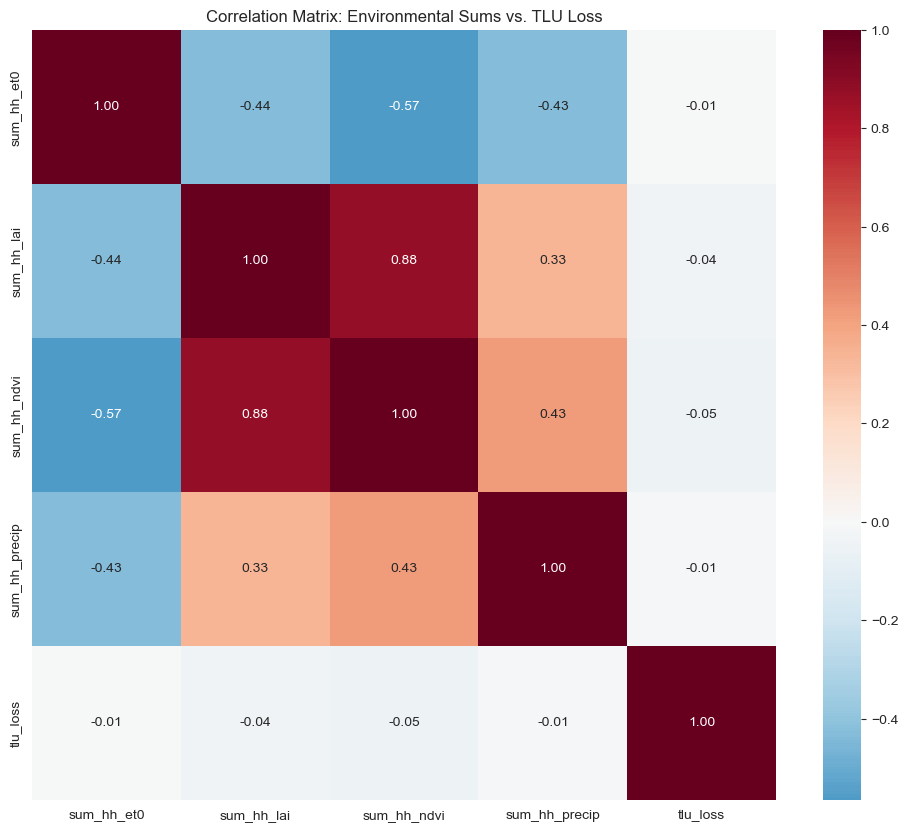

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sum_features = [col for col in merged_df.columns if 'sum' in col]
columns_to_correlate = sum_features + ['tlu_loss']

corr_matrix = merged_df[columns_to_correlate].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Correlation Matrix: Environmental Sums vs. TLU Loss')
plt.show()

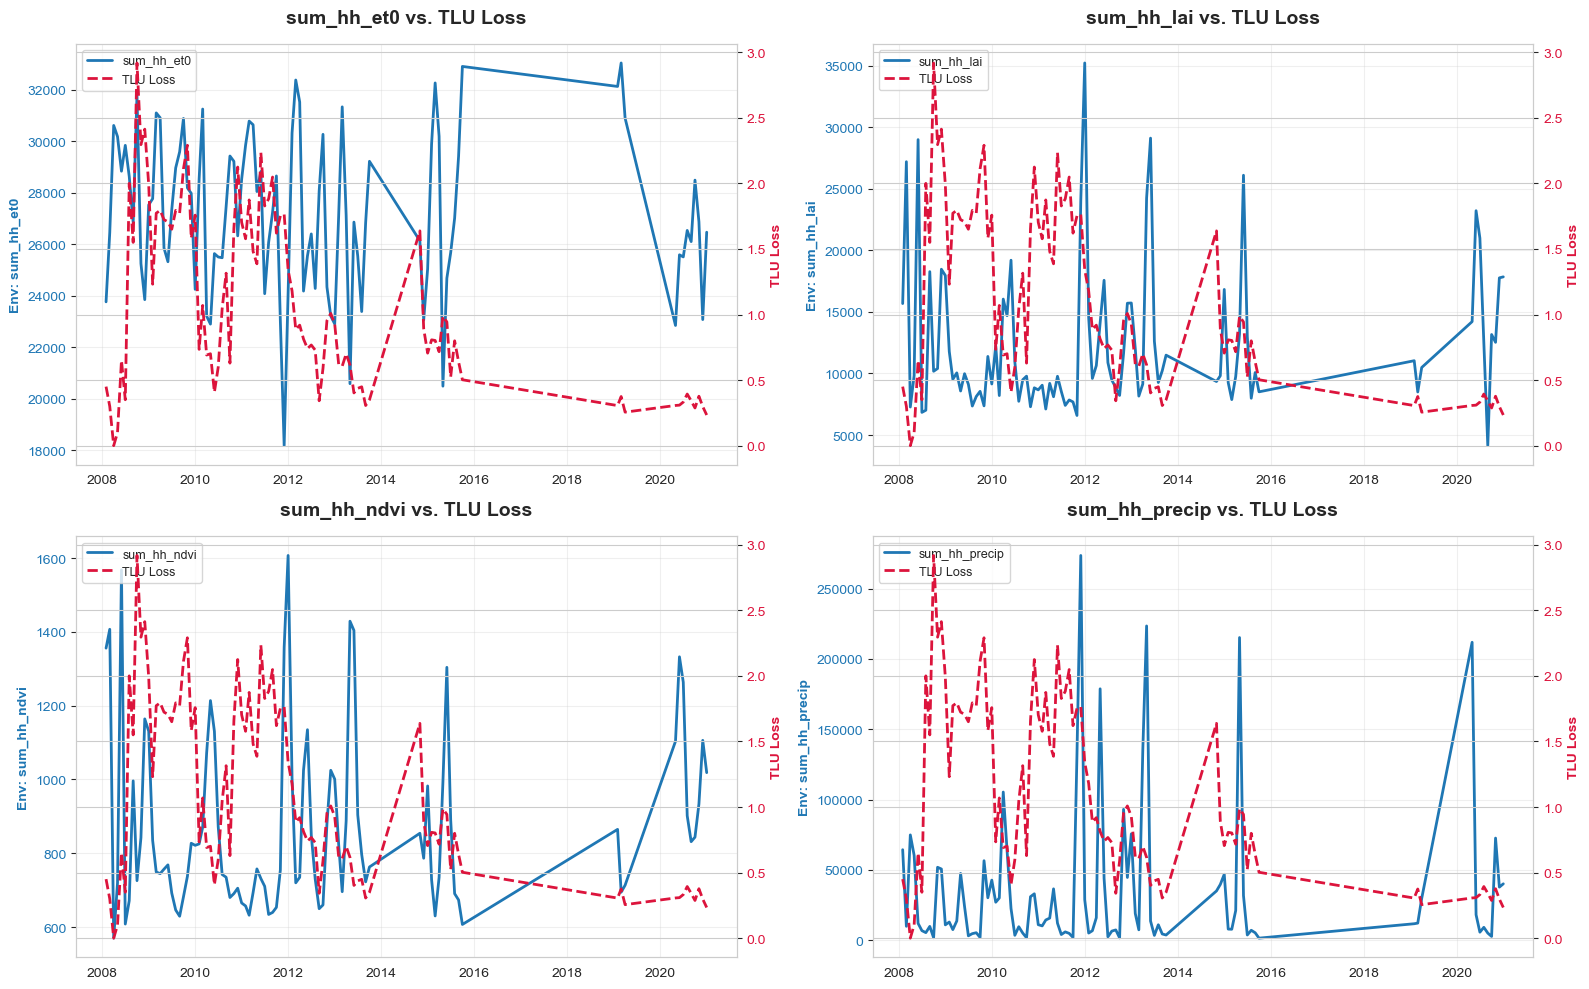

In [40]:
# 1. Identify input variables and target
sum_cols = [col for col in merged_df.columns if 'sum' in col]

# Aggregate data by time (mean across all zones) for a global trend
df_trend = merged_df.groupby('time').mean(numeric_only=True).reset_index().sort_values('time')

# 2. Setup the subplot grid
num_vars = len(sum_cols)
ncols = 2
nrows = (num_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

# 3. Loop through each environmental variable
for i, env_var in enumerate(sum_cols):
    ax1 = axes[i]
    
    # Plot Environmental Variable (Left Y-Axis - Blue)
    line1 = ax1.plot(df_trend['time'], df_trend[env_var], color='tab:blue', 
                     label=env_var, linewidth=2)
    ax1.set_ylabel(f'Env: {env_var}', color='tab:blue', fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Create a twin axis for TLU Loss (Right Y-Axis - Crimson)
    ax2 = ax1.twinx()
    line2 = ax2.plot(df_trend['time'], df_trend['tlu_loss'], color='crimson', 
                     label='TLU Loss', linewidth=2, linestyle='--')
    ax2.set_ylabel('TLU Loss', color='crimson', fontsize=10, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    # Title and Formatting
    ax1.set_title(f'{env_var} vs. TLU Loss', fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3)
    
    # Combine legends from both axes into one
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=9, frameon=True)

# 4. Remove any unused subplot axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

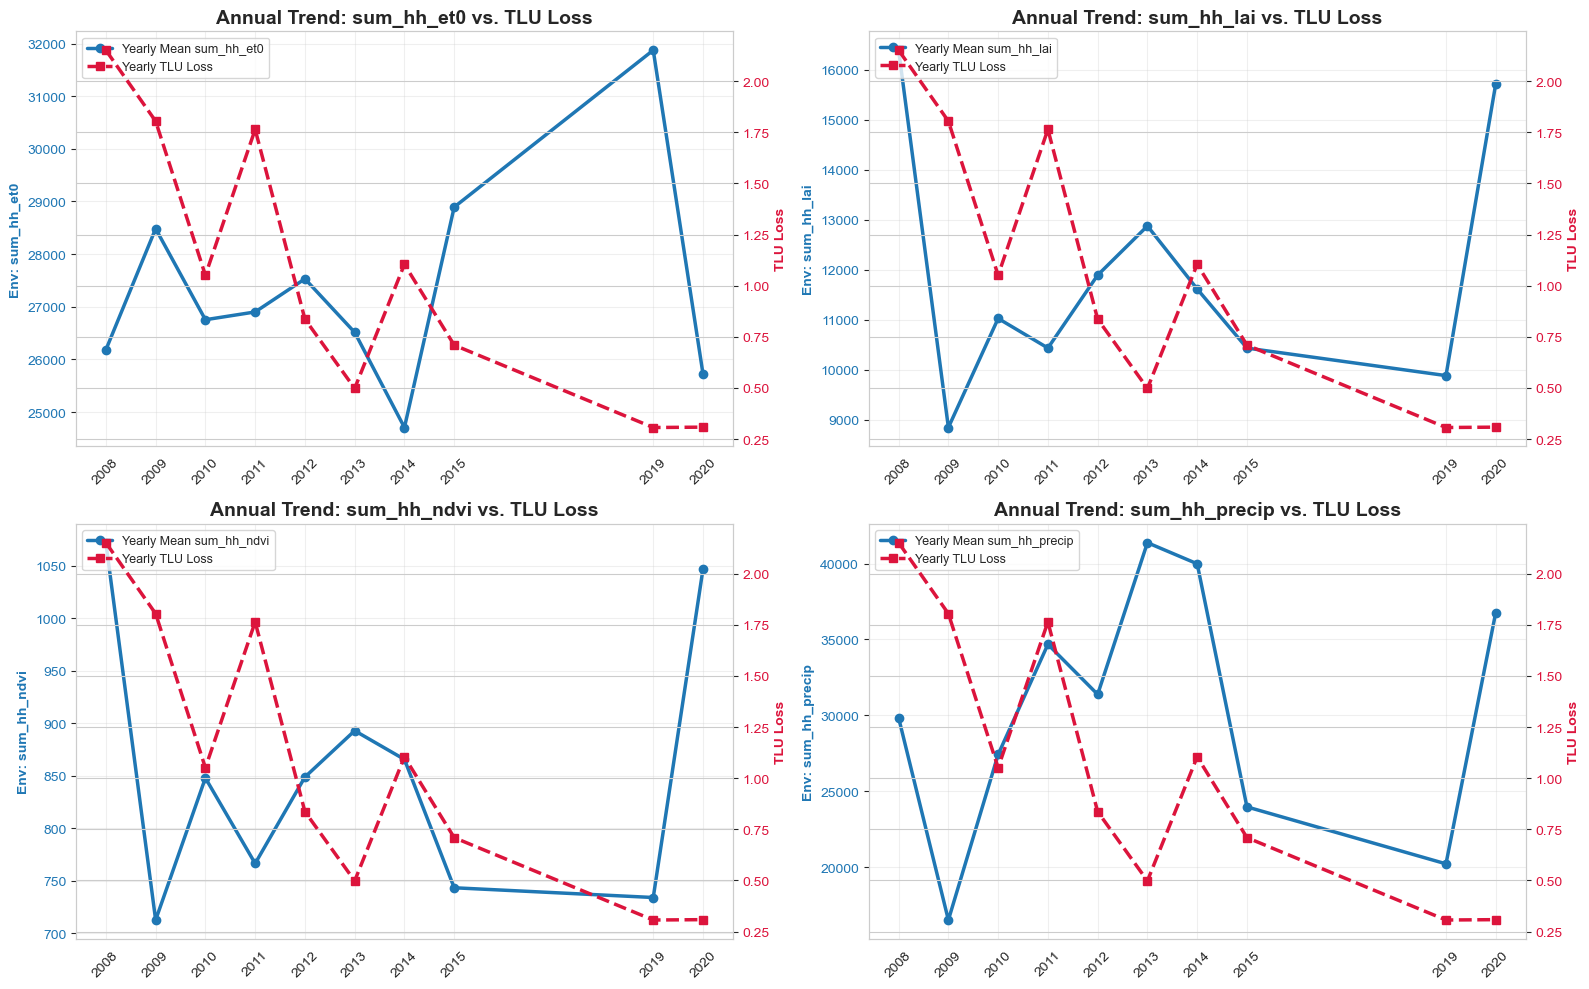

In [42]:
# 1. Identify environmental variables and target
sum_cols = [col for col in merged_df.columns if 'sum' in col]

# 2. Aggregate data by YEAR
# We use numeric_only=True to avoid the same TypeError from before
df_yearly = merged_df.groupby('year').mean(numeric_only=True).reset_index().sort_values('year')

# 3. Setup the subplot grid
num_vars = len(sum_cols)
ncols = 2
nrows = (num_vars + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

# 4. Loop through each environmental variable
for i, env_var in enumerate(sum_cols):
    ax1 = axes[i]
    
    # Plot Environmental Variable (Left Y-Axis - Blue)
    line1 = ax1.plot(df_yearly['year'], df_yearly[env_var], color='tab:blue', 
                     marker='o', label=f'Yearly Mean {env_var}', linewidth=2.5)
    ax1.set_ylabel(f'Env: {env_var}', color='tab:blue', fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Create a twin axis for TLU Loss (Right Y-Axis - Crimson)
    ax2 = ax1.twinx()
    line2 = ax2.plot(df_yearly['year'], df_yearly['tlu_loss'], color='crimson', 
                     marker='s', label='Yearly TLU Loss', linewidth=2.5, linestyle='--')
    ax2.set_ylabel('TLU Loss', color='crimson', fontsize=10, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    # Title and Formatting
    ax1.set_title(f'Annual Trend: {env_var} vs. TLU Loss', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Combined legend
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left', fontsize=9)
    
    # Force X-axis to show every year as an integer
    ax1.set_xticks(df_yearly['year'])
    plt.setp(ax1.get_xticklabels(), rotation=45)

# 5. Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Data manipulation to prep for training

In [96]:
# read in targets
losses = pd.read_csv('../data/IBLIData_CSV_PublicZipped/livestock_losses_spatial.csv')
losses = losses.rename(columns={'s6q24a':'num_loss_events', 's6q22b':'other_loss_cause'})

# .a and .b correspond to 'I don't know' and 'refuse to answer' -- drop rows where these are the year/month
losses = losses.loc[~((losses.year=='.a')|
                     (losses.month=='.a')|
                     (losses.year=='.b')|
                     (losses.month=='.b'))]

losses['hhid'] = losses['hhid'].astype(int)
losses['year'] = losses['year'].astype(int)
losses['month'] = losses['month'].astype(int)

print('losses:')
print(losses.shape)

# read in predictors
hdc_df = pd.read_csv('../data/hdc_master_combined_data.csv')
print('hdc_df:')
print(hdc_df.shape)

losses:
(14383, 20)
hdc_df:
(1881928, 20)


In [97]:
# Loss data only has information when there's a loss. We need to do some manipulation to create a monthly HH dataset

# Round coordinates to avoid floating point precision issues
losses['gps_latitude_rounded'] = losses['gps_latitude'].round(6)
losses['gps_longitude_rounded'] = losses['gps_longitude'].round(6)

# Agg losses by household, location, year, month
# A household could move over the survey period
monthly_losses = losses.groupby([
    'hhid', 
    'gps_latitude_rounded', 
    'gps_longitude_rounded',
    'year', 
    'month'
]).agg({
    'tlu_loss': 'sum'
}).reset_index()

# Get all unique household-location combinations with their date ranges
location_ranges = losses.groupby([
    'hhid',
    'gps_latitude_rounded',
    'gps_longitude_rounded'
]).agg({
    'year': ['min', 'max'],
    'month': ['min', 'max']
}).reset_index()

# Get date range for each household-location combination
complete_data = []

for _, row in location_ranges.iterrows():
    hhid = row[('hhid', '')]
    lat = row[('gps_latitude_rounded', '')]
    lon = row[('gps_longitude_rounded', '')]
    min_year = int(row[('year', 'min')])
    max_year = int(row[('year', 'max')])
    min_month = int(row[('month', 'min')])
    max_month = int(row[('month', 'max')])
    
    # Create all year-month combinations for this household-location
    for year in range(min_year, max_year + 1):
        if year in [2016, 2017, 2018]: # skip years with missing data capture
            continue
        for month in range(1, 13):
            # Only include months within the actual range
            if (year == min_year and month < min_month) or \
               (year == max_year and month > max_month):
                continue
            complete_data.append({
                'hhid': hhid,
                'gps_latitude': lat,
                'gps_longitude': lon,
                'year': year,
                'month': month
            })

complete_df = pd.DataFrame(complete_data)

# merge with aggregated losses and fill missing values with 0
result = complete_df.merge(
    monthly_losses,
    left_on=['hhid', 'gps_latitude', 'gps_longitude', 'year', 'month'],
    right_on=['hhid', 'gps_latitude_rounded', 'gps_longitude_rounded', 'year', 'month'],
    how='left'
)
result = result.drop(columns=['gps_latitude_rounded', 'gps_longitude_rounded'])
result['tlu_loss'] = result['tlu_loss'].fillna(0)

# set date to last day of month -- this is an assumption
result['tlu_date'] = pd.to_datetime(result[['year', 'month']].assign(day=1)) + pd.offsets.MonthEnd(0)

# assign dekad 3 (end of month)
result['tlu_dekad'] = 3

# add season using Matt's logic from notebook 01
result['season'] = np.where((result['month']>=3)&(result['month']<=9),
                            'LRLD',
                            'SRSD')

result = result.sort_values(['hhid', 'gps_latitude', 'gps_longitude', 'year', 'month']).reset_index(drop=True)
result = result[[
    'hhid', 
    'gps_latitude', 
    'gps_longitude',
    'tlu_date',
    'year', 
    'month',
    'tlu_dekad',
    'tlu_loss', 
    'season'
]]

display(result.head(12))
print(f"\nTotal rows: {len(result)}")
print(f"Unique households: {result['hhid'].nunique()}")
print(f"Unique household-location combinations: {result.groupby(['hhid', 'gps_latitude', 'gps_longitude']).ngroups}")

,hhid,gps_latitude,gps_longitude,tlu_date,year,month,tlu_dekad,tlu_loss,season
0,1002.0,2.5,38.299999,2009-01-31,2009,1,3,0.0,SRSD
1,1002.0,2.5,38.299999,2009-02-28,2009,2,3,0.0,SRSD
2,1002.0,2.5,38.299999,2009-03-31,2009,3,3,0.0,LRLD
3,1002.0,2.5,38.299999,2009-04-30,2009,4,3,0.0,LRLD
4,1002.0,2.5,38.299999,2009-05-31,2009,5,3,0.0,LRLD
5,1002.0,2.5,38.299999,2009-06-30,2009,6,3,0.0,LRLD
6,1002.0,2.5,38.299999,2009-07-31,2009,7,3,1.0,LRLD
7,1002.0,2.5,38.299999,2009-08-31,2009,8,3,0.3,LRLD
8,1002.0,2.5,38.299999,2009-09-30,2009,9,3,2.0,LRLD
9,1002.0,2.5,38.299999,2009-10-31,2009,10,3,0.0,SRSD



Total rows: 88905
Unique households: 1026
Unique household-location combinations: 1026


In [102]:
# result[result.year==2019].hhid.sample(10)
result[(result.hhid==6013.0)&(result.year==2015)]

,hhid,gps_latitude,gps_longitude,tlu_date,year,month,tlu_dekad,tlu_loss,season
25843,6013.0,3.4,37.599998,2015-01-31,2015,1,3,0.0,SRSD
25844,6013.0,3.4,37.599998,2015-02-28,2015,2,3,0.0,SRSD
25845,6013.0,3.4,37.599998,2015-03-31,2015,3,3,0.0,LRLD
25846,6013.0,3.4,37.599998,2015-04-30,2015,4,3,0.0,LRLD
25847,6013.0,3.4,37.599998,2015-05-31,2015,5,3,0.0,LRLD
25848,6013.0,3.4,37.599998,2015-06-30,2015,6,3,0.0,LRLD
25849,6013.0,3.4,37.599998,2015-07-31,2015,7,3,0.0,LRLD
25850,6013.0,3.4,37.599998,2015-08-31,2015,8,3,0.0,LRLD
25851,6013.0,3.4,37.599998,2015-09-30,2015,9,3,0.0,LRLD
25852,6013.0,3.4,37.599998,2015-10-31,2015,10,3,0.0,SRSD


In [84]:
# join inputs and targets - keep at dekad level
hdc_df['hdc_date'] = pd.to_datetime(hdc_df['time'])
hdc_df['month'] = hdc_df.hdc_date.dt.month
hdc_df['year'] = hdc_df.hdc_date.dt.year
full_df = hdc_df.merge(result,
                       left_on=['zone', 'year', 'month'],
                       right_on=['hhid', 'year', 'month'])
full_df['hdc_dekad'] = ((full_df['hdc_date'].dt.day - 1) // 10 + 1).clip(upper=3)
full_df['season_lrld_ind'] = np.where(full_df['season']=='LRLD', 1, 0)
full_df = full_df[['hhid',
                   'hdc_date',
                   'hdc_dekad',
                   'mean_hh_et0',
                   'sum_hh_et0',
                   'mean_hh_lai',
                   'sum_hh_lai',
                   'TNA_mean_hh_lst',
                   'TNA_min_hh_lst',
                   'TNA_max_hh_lst',
                   'TDA_mean_hh_lst',
                   'TDA_min_hh_lst',
                   'TDA_max_hh_lst',
                   'mean_hh_ndvi',
                   'sum_hh_ndvi',
                   'hhid_hh_ndvi',
                   'round_hh_ndvi',
                   'gps_latitude_hh_ndvi',
                   'gps_longitude_hh_ndvi',
                   'mean_hh_precip',
                   'sum_hh_precip',
                   'hhid',
                   'gps_latitude',
                   'gps_longitude',
                   'tlu_date',
                   'tlu_dekad',
                   'tlu_loss',
                   'season',
                   'season_lrld_ind']]

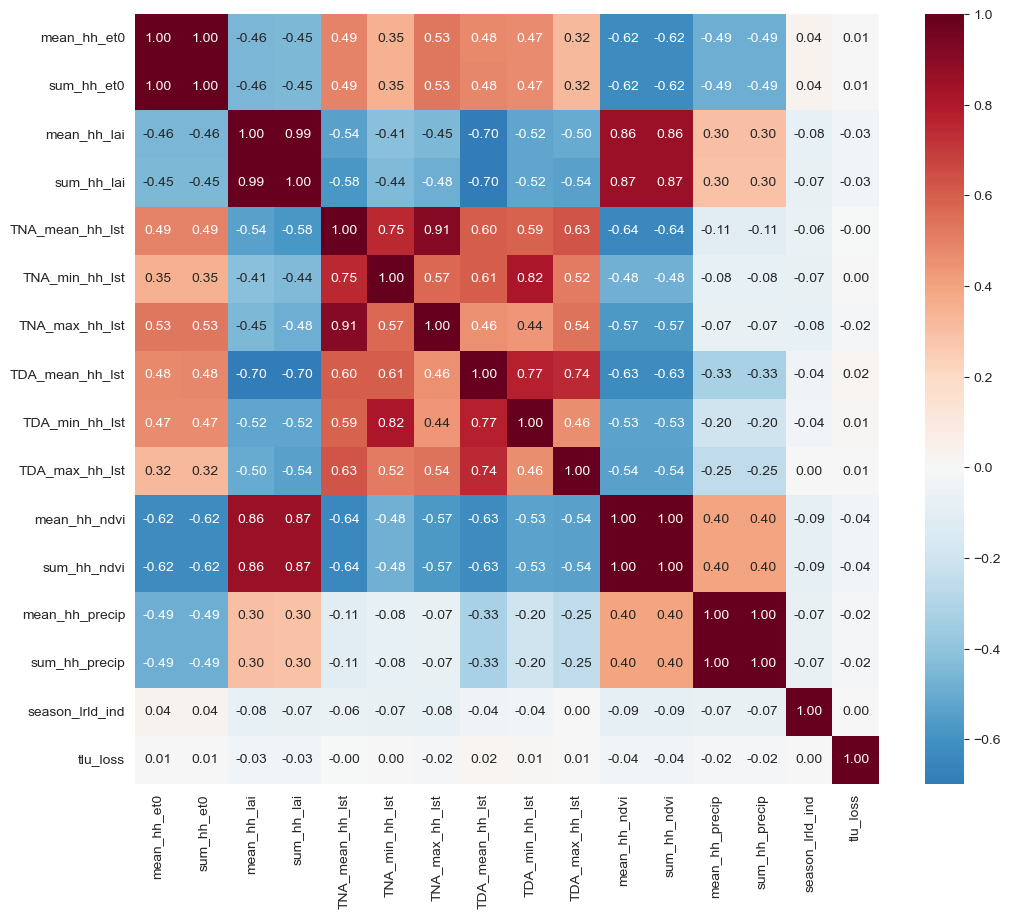

In [88]:
columns_to_correlate = ['mean_hh_et0',
                   'sum_hh_et0',
                   'mean_hh_lai',
                   'sum_hh_lai',
                   'TNA_mean_hh_lst',
                   'TNA_min_hh_lst',
                   'TNA_max_hh_lst',
                   'TDA_mean_hh_lst',
                   'TDA_min_hh_lst',
                   'TDA_max_hh_lst',
                   'mean_hh_ndvi',
                   'sum_hh_ndvi',
                #    'hhid_hh_ndvi',
                #    'round_hh_ndvi',
                #    'gps_latitude_hh_ndvi',
                #    'gps_longitude_hh_ndvi',
                #    'gps_latitude',
                #    'gps_longitude',
                   'mean_hh_precip',
                   'sum_hh_precip',
                   'season_lrld_ind',
                   'tlu_loss']

corr_matrix = full_df[columns_to_correlate].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.show()


Dekad 1 - Sample size: 370181

Dekad 2 - Sample size: 355375

Dekad 3 - Sample size: 370791


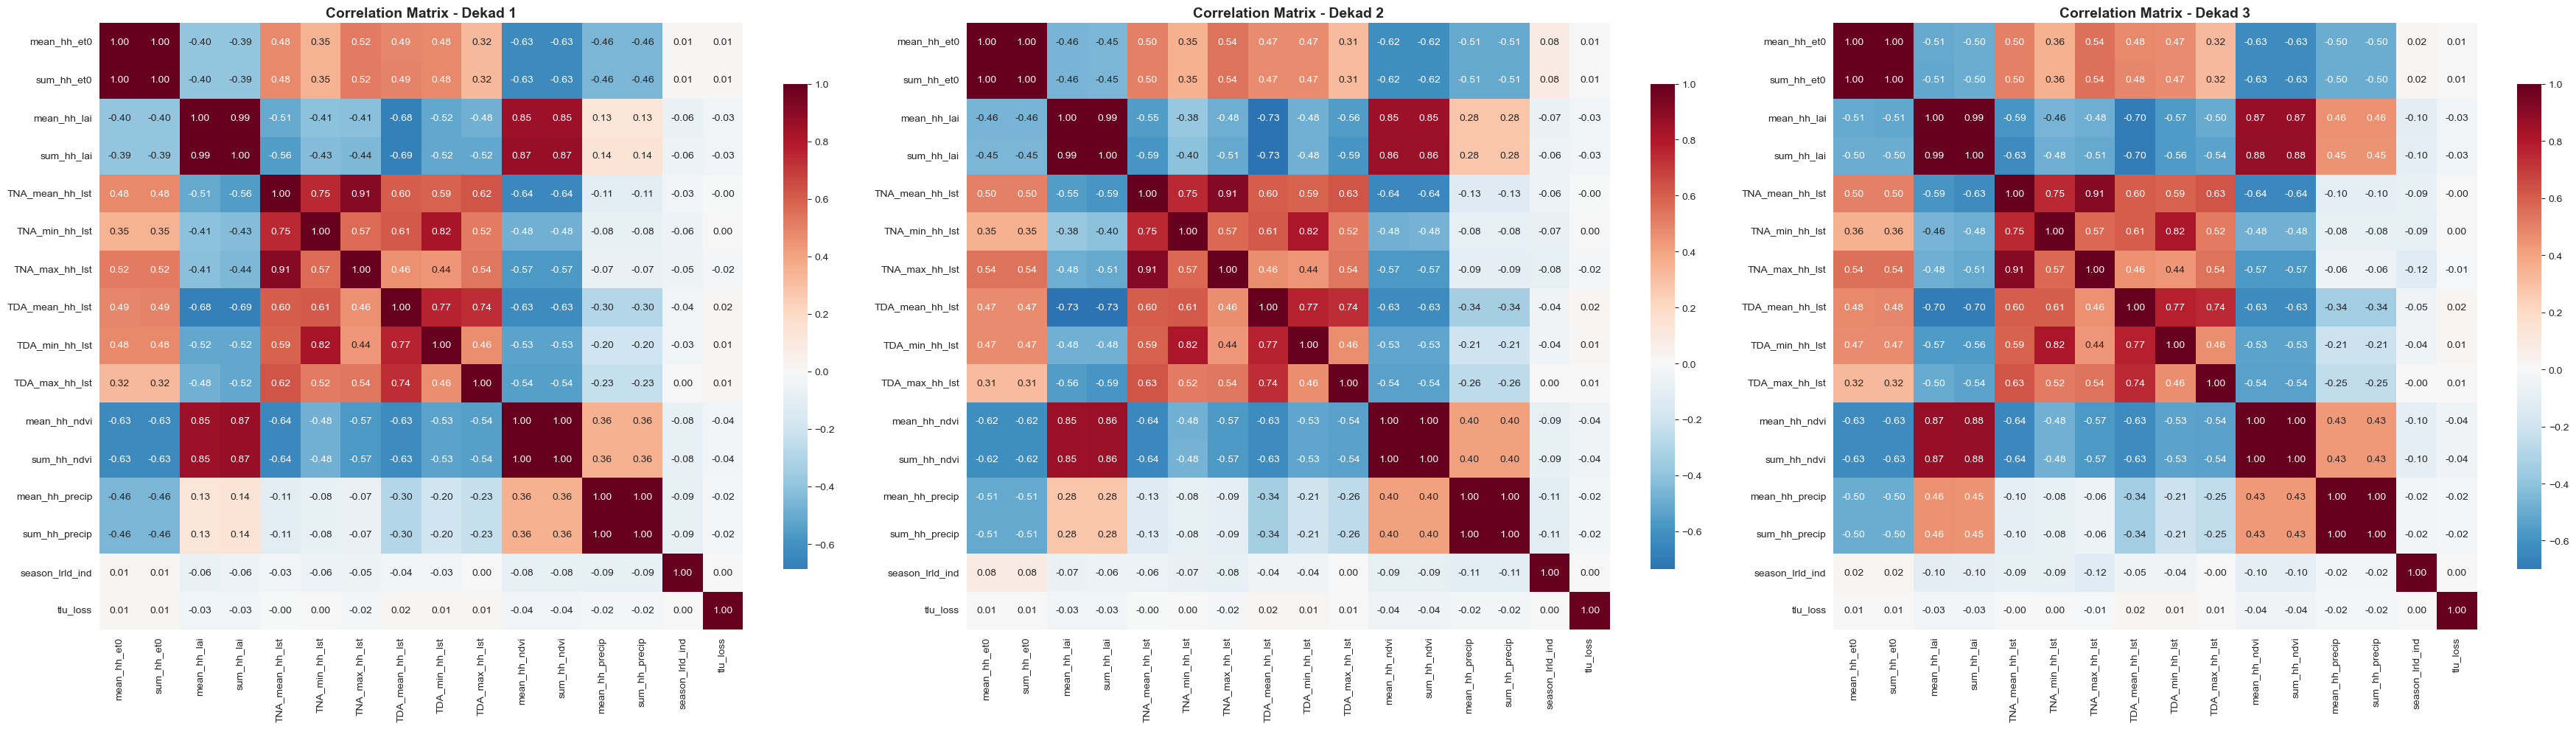

In [89]:
columns_to_correlate = ['mean_hh_et0',
                   'sum_hh_et0',
                   'mean_hh_lai',
                   'sum_hh_lai',
                   'TNA_mean_hh_lst',
                   'TNA_min_hh_lst',
                   'TNA_max_hh_lst',
                   'TDA_mean_hh_lst',
                   'TDA_min_hh_lst',
                   'TDA_max_hh_lst',
                   'mean_hh_ndvi',
                   'sum_hh_ndvi',
                   'mean_hh_precip',
                   'sum_hh_precip',
                   'season_lrld_ind',
                   'tlu_loss']

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(36, 10))

# Loop through each dekad
for dekad in [1, 2, 3]:
    # Filter data for current dekad
    dekad_df = full_df[full_df['hdc_dekad'] == dekad]
    
    # Calculate correlation matrix
    corr_matrix = dekad_df[columns_to_correlate].corr()
    
    # Create heatmap
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='RdBu_r', 
                center=0, 
                fmt=".2f",
                ax=axes[dekad-1],
                cbar_kws={'shrink': 0.8})
    
    axes[dekad-1].set_title(f'Correlation Matrix - Dekad {dekad}', fontsize=14, fontweight='bold')
    
    # Print some statistics
    print(f"\nDekad {dekad} - Sample size: {len(dekad_df)}")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: build in lagged target
# Sort the dataframe by household, location, and date to ensure proper ordering
full_df = full_df.sort_values(['hhid', 'gps_latitude', 'gps_longitude', 'hdc_date']).reset_index(drop=True)

# Create lagged target variables (future losses)
# We'll use groupby to ensure lags are calculated within each household-location combination
groupby_cols = ['hhid', 'gps_latitude', 'gps_longitude']

# This groups by household-location-year-month and aggregates to monthly level first
monthly_losses = full_df.groupby(['hhid', 'gps_latitude', 'gps_longitude', 'year', 'month'])['tlu_loss'].sum().reset_index()
monthly_losses = monthly_losses.sort_values(['hhid', 'gps_latitude', 'gps_longitude', 'year', 'month']).reset_index(drop=True)

# Create future month losses
monthly_losses['tlu_loss_1m_future'] = monthly_losses.groupby(['hhid', 'gps_latitude', 'gps_longitude'])['tlu_loss'].shift(-1)
monthly_losses['tlu_loss_2m_future'] = monthly_losses.groupby(['hhid', 'gps_latitude', 'gps_longitude'])['tlu_loss'].shift(-2)
monthly_losses['tlu_loss_3m_future'] = monthly_losses.groupby(['hhid', 'gps_latitude', 'gps_longitude'])['tlu_loss'].shift(-3)

# Merge back to the full dataframe
full_df = full_df.merge(
    monthly_losses[['hhid', 'gps_latitude', 'gps_longitude', 'year', 'month', 
                    'tlu_loss_1m_future', 'tlu_loss_2m_future', 'tlu_loss_3m_future']],
    on=['hhid', 'gps_latitude', 'gps_longitude', 'year', 'month'],
    how='left'
)

# Check the results
print("Lagged target variables created:")
print(full_df[['hhid', 'hdc_date', 'year', 'month', 'tlu_loss', 
               'tlu_loss_1m', 'tlu_loss_2m', 'tlu_loss_3m',
               'tlu_loss_1m_future', 'tlu_loss_2m_future', 'tlu_loss_3m_future']].head(20))

print(f"\nMissing values in lagged targets:")
print(full_df[['tlu_loss_1m', 'tlu_loss_2m', 'tlu_loss_3m', 
               'tlu_loss_1m_future', 'tlu_loss_2m_future', 'tlu_loss_3m_future']].isnull().sum())

# Example: Filter out rows where we don't have future targets (useful for training)
training_df = full_df[full_df['tlu_loss_3m_future'].notna()].copy()
print(f"\nOriginal data size: {len(full_df)}")
print(f"Training data size (with all 3-month future targets): {len(training_df)}")


In [ ]:
# TODO: anomaly-based features